### LVK GWTC 4.0 Full Pop

We cannot use this directly because the maximum mass used here to calculate rates per mass bin is 2.5 $M_{\odot}$ but for SFHo, its 2.25 $M_{\odot}$. Needs tweaks.

opening existing popsummary file: /ligo/home/ligo.org/sanika.khadkikar/Projects/et-centric/fisher_scripts/data/AllCBC_FullPop.h5


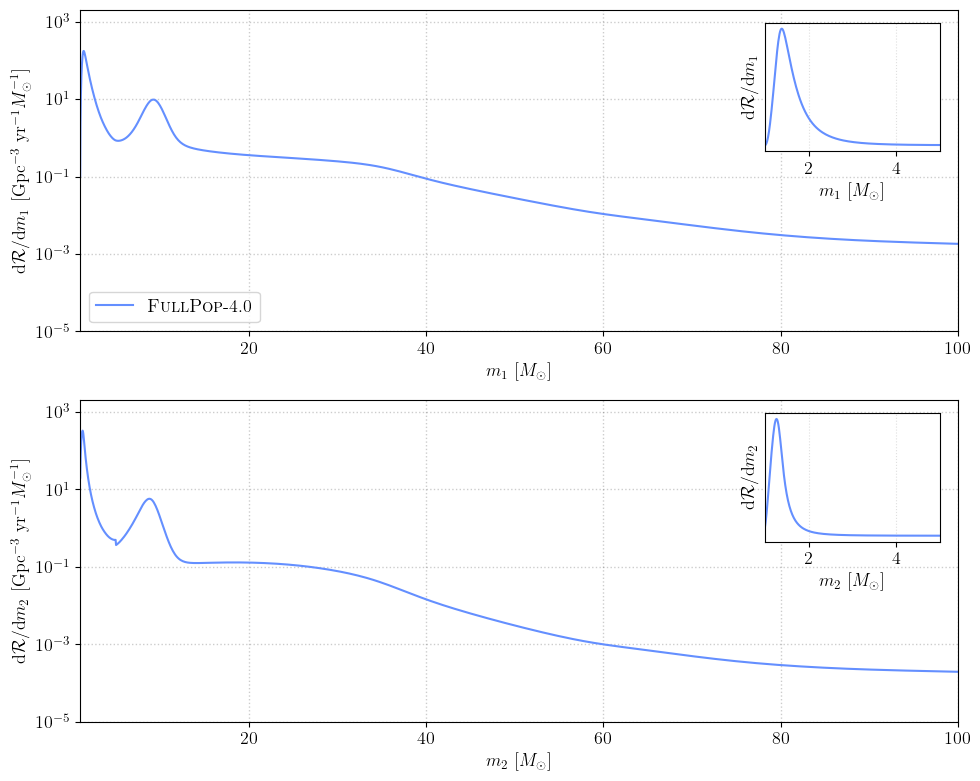

In [1]:
import numpy as np
import popsummary
from matplotlib import pyplot as plt
from gwpopulation.utils import powerlaw, truncnorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=13)

fig, axes = plt.subplots(nrows=2, figsize=(10,8))

DATADIR = "/ligo/home/ligo.org/sanika.khadkikar/Projects/et-centric/fisher_scripts/data/"
pdb_file = DATADIR + 'AllCBC_FullPop.h5'
pdb_result = popsummary.popresult.PopulationResult(fname=pdb_file)

mass_key = ['primary_mass', 'secondary_mass']
color2 = '#FE6100'
color1 = '#648FFF'
for ii in range(1,3):
    ax = axes[ii-1]
    pdb_m, pdb_Rm = pdb_result.get_rates_on_grids(mass_key[ii-1])
    #ax.fill_between(pdb_m[0], np.percentile(pdb_Rm, 5, axis=0), np.percentile(pdb_Rm, 95, axis=0), color=color1, alpha=0.3, rasterized=True)

    ax.plot(pdb_m[0], np.mean(pdb_Rm, axis=0), color=color1, label=r'\textsc{FullPop}-4.0')
    ax.set_yscale('log')
    ax.set_ylim(1e-5, 2e3)
    ax.set_xlim(1,100)
    ax.set_ylabel(f'$\\textrm{{d}}\mathcal{{R}}/\\textrm{{d}}m_{ii}$ [Gpc${{}}^{{-3}}$ yr${{}}^{{-1}}M_\odot^{{-1}}$]')
    ax.set_xlabel(f'$m_{ii}$ [$M_\odot$]')
    ax.grid(ls = ':', alpha = 0.2, lw = 1, color = 'k')

    axes[0].legend(frameon=True, loc='lower left')
    inset = axes[ii-1].inset_axes([0.78, 0.56, 0.2, 0.4])
    
    inset.plot(pdb_m[0], np.mean(pdb_Rm, axis=0), color=color1, label=r'\textsc{FullPop}-4.0')
    inset.set_xlabel(f'$m_{ii}$ [$M_\odot$]')
    inset.set_ylabel(f'$\\textrm{{d}}\mathcal{{R}}/\\textrm{{d}}m_{ii}$')
    inset.set_xlim(1,5)
    inset.set_yticks([])
    inset.grid(color='silver', alpha=0.5, ls=':')

plt.tight_layout()

### Full Pop Explained for Plotting it From Scratch (for demonstration only. We can just use the first cell)

This can by itself be used as the mass distribution

opening existing popsummary file: /ligo/home/ligo.org/sanika.khadkikar/Projects/et-centric/fisher_scripts/data/AllCBC_FullPop.h5


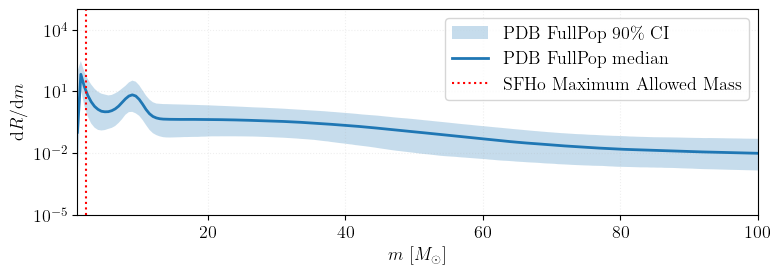

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import popsummary
from scipy.stats import norm

#Truncated Gaussian distribution for the 9 Msol and 27 Msol peaks
def truncated_normal(m, mu, sigma, mmin, mmax):
    """Truncated normal distribution normalized over [mmin, mmax].""" 
    from scipy.stats import norm 
    norm_const = norm.cdf((mmax - mu) / sigma) - norm.cdf((mmin - mu) / sigma) 
    pdf = norm.pdf((m - mu) / sigma) / (sigma * norm_const) 
    pdf[(m < mmin) | (m > mmax)] = 0 
    return pdf

#This is a low pass filter to smoothen out BHSs at the heavy end of the distribution (500 Msol)
def l(m, m_BHmax, eta_BHmax):
    return 1.0 / (1.0 + (m / m_BHmax)**eta_BHmax)

#This is a high pass filter to smoothen out NSs at the lighter end of the distribution (1 Msol)
def h(m, m_NSmin, eta_NSmin):
    return 1.0 - l(m, m_NSmin, eta_NSmin)

#Notch Filter to represent a dip due to the Lower Mass Gap
def n1(m, m_NSmax, m_BHmin, eta_NSmax, eta_BHmin, A):
    return 1.0 - A * l(m, m_NSmax, eta_NSmax) * h(m, m_BHmin, eta_BHmin)

#Notch Filter to represent a dip due to the Upper Mass Gap
def n2(m, m_UMGmin, m_UMGmax, eta_UMGmin, eta_UMGmax, A2):
    return 1.0 - A2 * l(m, m_UMGmin, eta_UMGmin) * h(m, m_UMGmax, eta_UMGmax)

#Combined mass probabilty function 
def pi_m(m, alpha_1, alpha_dip, alpha_2, m_NSmin, m_NSmax, m_BHmin, m_BHmax,
    m_UMGmin, m_UMGmax, eta_NSmin, eta_NSmax, eta_BHmin, eta_BHmax, eta_UMGmin,
    eta_UMGmax, c1, mu1, sigma1, c2, mu2, sigma2, A, A2, mmin, mmax,):

    # Upper over density truncated normal gaussian at 27 Msol
    g1 = truncated_normal(m, mu1, sigma1, mmin, mmax)

    # Lower over density truncated normal gaussian at 9 Msol
    g2 = truncated_normal(m, mu2, sigma2, mmin, mmax)

    # Combining these with c1 and c2 mixing fractions
    peak_term = 1.0 + c1 * g1 + c2 * g2

    # First notch filter for lower mass gap
    n1_term = n1(m, m_NSmax, m_BHmin, eta_NSmax, eta_BHmin, A)

    # Second notch filter for upper mass gap
    n2_term = n2(m, m_UMGmin, m_UMGmax, eta_UMGmin, eta_UMGmax, A2)

    # High pass filter to smoothen out lower mass cut-off
    h_term = h(m, m_NSmin, eta_NSmin)

    # Low pass filter to smoothen out higher mass cut-off
    l_term = l(m, m_BHmax, eta_BHmax)

    # piecewise power law with dip
    power = np.zeros_like(m)
    mask1 = m < m_NSmax
    mask2 = (m >= m_NSmax) & (m < m_BHmin)
    mask3 = m >= m_BHmin

    power[mask1] = m[mask1]**alpha_1
    power[mask2] = (m[mask2]**alpha_dip) * (m_NSmax**(alpha_1 - alpha_dip))
    power[mask3] = (m[mask3]**alpha_2) * (m_NSmax**(alpha_1 - alpha_dip)) * (m_BHmin**(alpha_dip - alpha_2))

    return peak_term * n1_term * n2_term * h_term * l_term * power


if __name__ == "__main__":
    ns_file = DATADIR + "AllCBC_FullPop.h5"
    ns_result = popsummary.popresult.PopulationResult(fname=ns_file)

    # Hyperparameter posteriors (arrays, all same length N)

    # 27 Msol peak hyperparameters
    mu1_s        = ns_result.get_hyperparameter_samples(hyperparameters=["mu1"])
    sigma1_s     = ns_result.get_hyperparameter_samples(hyperparameters=["sig1"])
    c1_s         = ns_result.get_hyperparameter_samples(hyperparameters=["mix1"])
    A_s          = ns_result.get_hyperparameter_samples(hyperparameters=["A"])

    # 9 Msol peak hyperparameters
    mu2_s        = ns_result.get_hyperparameter_samples(hyperparameters=["mu2"])
    sigma2_s     = ns_result.get_hyperparameter_samples(hyperparameters=["sig2"])
    c2_s         = ns_result.get_hyperparameter_samples(hyperparameters=["mix2"])
    A2_s         = ns_result.get_hyperparameter_samples(hyperparameters=["A2"])

    # First notch filter hyperparameters
    m_NSmax_s    = ns_result.get_hyperparameter_samples(hyperparameters=["NSmax"])   # gamma_1_low
    m_BHmin_s    = ns_result.get_hyperparameter_samples(hyperparameters=["BHmin"])   # gamma_1_high
    eta_NSmax_s  = ns_result.get_hyperparameter_samples(hyperparameters=["n1"])
    eta_BHmin_s  = ns_result.get_hyperparameter_samples(hyperparameters=["n2"])

    # Second notch filter hyperparameters
    m_UMGmin_s   = ns_result.get_hyperparameter_samples(hyperparameters=["UPPERmin"])  # gamma_2_low
    m_UMGmax_s   = ns_result.get_hyperparameter_samples(hyperparameters=["UPPERmax"])  # gamma_2_high
    eta_UMGmin_s = ns_result.get_hyperparameter_samples(hyperparameters=["n3"])
    eta_UMGmax_s = ns_result.get_hyperparameter_samples(hyperparameters=["n4"])

    # High pass filter hyperparameters
    m_NSmin_s    = ns_result.get_hyperparameter_samples(hyperparameters=["NSmin"])
    eta_NSmin_s  = ns_result.get_hyperparameter_samples(hyperparameters=["n0"])

    # Low pass filter hyperparameters
    m_BHmax_s    = ns_result.get_hyperparameter_samples(hyperparameters=["BHmax"])
    eta_BHmax_s  = ns_result.get_hyperparameter_samples(hyperparameters=["n5"])

    # Power law hyperparameters
    alpha_1_s    = ns_result.get_hyperparameter_samples(hyperparameters=["alpha_1"])
    alpha_2_s    = ns_result.get_hyperparameter_samples(hyperparameters=["alpha_2"])
    alpha_dip_s  = ns_result.get_hyperparameter_samples(hyperparameters=["alpha_dip"])

    # Local merger rate density
    rate_full_s  = ns_result.get_hyperparameter_samples(hyperparameters=["rate_full"])

    # Ensure consistent length
    N = min(
        len(mu1_s), len(sigma1_s), len(c1_s), len(A_s),
        len(mu2_s), len(sigma2_s), len(c2_s), len(A2_s),
        len(m_NSmax_s), len(m_BHmin_s), len(eta_NSmax_s), len(eta_BHmin_s),
        len(m_UMGmin_s), len(m_UMGmax_s), len(eta_UMGmin_s), len(eta_UMGmax_s),
        len(m_NSmin_s), len(eta_NSmin_s),
        len(m_BHmax_s), len(eta_BHmax_s),
        len(alpha_1_s), len(alpha_2_s), len(alpha_dip_s),
        len(rate_full_s),
    )

    mmin, mmax = 1.0, 500.0
    m = np.linspace(1.0, 500.0, 1000)

    # dR/dm samples: N curves × 1000 mass points
    dRdm_samples = np.zeros((N, m.size))

    for i in range(N):
        pi_vals_i = pi_m(
            m,
            alpha_1_s[i], alpha_dip_s[i], alpha_2_s[i],
            m_NSmin_s[i], m_NSmax_s[i], m_BHmin_s[i], m_BHmax_s[i],
            m_UMGmin_s[i], m_UMGmax_s[i],
            eta_NSmin_s[i], eta_NSmax_s[i], eta_BHmin_s[i], eta_BHmax_s[i],
            eta_UMGmin_s[i], eta_UMGmax_s[i],
            c1_s[i], mu1_s[i], sigma1_s[i],
            c2_s[i], mu2_s[i], sigma2_s[i],
            A_s[i], A2_s[i],
            mmin, mmax,
        )
        # multiply by the scalar rate for this hyper-sample
        dRdm_samples[i, :] = pi_vals_i * rate_full_s[i]

    # Median and 90% interval across hyper-samples at each m
    rate_med = np.median(dRdm_samples, axis=0)
    rate_lo  = np.percentile(dRdm_samples, 5, axis=0)
    rate_hi  = np.percentile(dRdm_samples, 95, axis=0)

    plt.figure(figsize=(8, 3))
    plt.fill_between(m, rate_lo, rate_hi, alpha=0.25, label=r"PDB FullPop $90\%$ CI")
    plt.plot(m, rate_med, lw=2, label="PDB FullPop median")

    # Original reference (if pdb_m, pdb_Rm defined)
    #plt.plot(pdb_m[0], np.mean(pdb_Rm, axis=0), label=r'\textsc{FullPop}-4.0')

    plt.xlabel(r"$m\ [M_\odot]$")
    plt.axvline(2.25, label = 'SFHo Maximum Allowed Mass', color='red', ls=':')
    plt.ylabel(r"$\mathrm{d}R/\mathrm{d}m$")
    plt.xlim(1, 100)
    plt.yscale("log")
    plt.ylim(1e-5, 1e5)
    plt.grid(ls=":", alpha=0.2)
    plt.legend(frameon=True, loc="upper right")
    plt.tight_layout()
    plt.show()

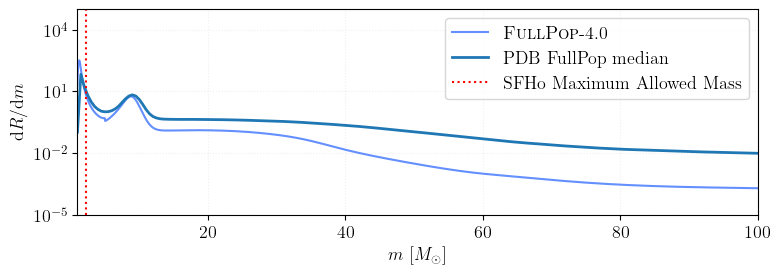

In [9]:
# Hyperparameter posteriors
maxl = np.argmax(ns_result.get_hyperparameter_samples(hyperparameters=["log_likelihood"]))

# Peaks
mu1_s        = ns_result.get_hyperparameter_samples(hyperparameters=["mu1"])[maxl]
sigma1_s     = ns_result.get_hyperparameter_samples(hyperparameters=["sig1"])[maxl]
c1_s         = ns_result.get_hyperparameter_samples(hyperparameters=["mix1"])[maxl]
A_s          = ns_result.get_hyperparameter_samples(hyperparameters=["A"])[maxl]

# 9 Msol peak hyperparameters
mu2_s        = ns_result.get_hyperparameter_samples(hyperparameters=["mu2"])[maxl]
sigma2_s     = ns_result.get_hyperparameter_samples(hyperparameters=["sig2"])[maxl]
c2_s         = ns_result.get_hyperparameter_samples(hyperparameters=["mix2"])[maxl]
A2_s         = ns_result.get_hyperparameter_samples(hyperparameters=["A2"])[maxl]

# First notch filter hyperparameters
m_NSmax_s    = ns_result.get_hyperparameter_samples(hyperparameters=["NSmax"])[maxl]   # gamma_1_low
m_BHmin_s    = ns_result.get_hyperparameter_samples(hyperparameters=["BHmin"])[maxl]   # gamma_1_high
eta_NSmax_s  = ns_result.get_hyperparameter_samples(hyperparameters=["n1"])[maxl]
eta_BHmin_s  = ns_result.get_hyperparameter_samples(hyperparameters=["n2"])[maxl]

# Second notch filter hyperparameters
m_UMGmin_s   = ns_result.get_hyperparameter_samples(hyperparameters=["UPPERmin"])[maxl]  # gamma_2_low
m_UMGmax_s   = ns_result.get_hyperparameter_samples(hyperparameters=["UPPERmax"])[maxl]  # gamma_2_high
eta_UMGmin_s = ns_result.get_hyperparameter_samples(hyperparameters=["n3"])[maxl]
eta_UMGmax_s = ns_result.get_hyperparameter_samples(hyperparameters=["n4"])[maxl]

# High pass filter hyperparameters
m_NSmin_s    = ns_result.get_hyperparameter_samples(hyperparameters=["NSmin"])[maxl]
eta_NSmin_s  = ns_result.get_hyperparameter_samples(hyperparameters=["n0"])[maxl]

# Low pass filter hyperparameters
m_BHmax_s    = ns_result.get_hyperparameter_samples(hyperparameters=["BHmax"])[maxl]
eta_BHmax_s  = ns_result.get_hyperparameter_samples(hyperparameters=["n5"])[maxl]

# Power law hyperparameters
alpha_1_s    = ns_result.get_hyperparameter_samples(hyperparameters=["alpha_1"])[maxl]
alpha_2_s    = ns_result.get_hyperparameter_samples(hyperparameters=["alpha_2"])[maxl]
alpha_dip_s  = ns_result.get_hyperparameter_samples(hyperparameters=["alpha_dip"])[maxl]

# Local merger rate density
rate_full_maxl  = ns_result.get_hyperparameter_samples(hyperparameters=["rate_full"])[maxl]

# Mass grid
mmin, mmax = 1.0, 500.0
m = np.linspace(mmin, mmax, 1000)

# Compute dR/dm
dRdm_samples = np.zeros((1, m.size))  # only using max-likelihood sample here
pi_vals = pi_m(
    m,
    alpha_1_s, alpha_dip_s, alpha_2_s,
    m_NSmin_s, m_NSmax_s, m_BHmin_s, m_BHmax_s,
    m_UMGmin_s, m_UMGmax_s,
    eta_NSmin_s, eta_NSmax_s, eta_BHmin_s, eta_BHmax_s,
    eta_UMGmin_s, eta_UMGmax_s,
    c1_s, mu1_s, sigma1_s,
    c2_s, mu2_s, sigma2_s,
    A_s, A2_s, mmin, mmax
)
dRdm_samples[0, :] = pi_vals * rate_full_maxl

plt.figure(figsize=(8, 3))
# plt.fill_between(m, rate_lo, rate_hi, alpha=0.25, label=r"PDB FullPop 90% CI")
plt.plot(pdb_m[0], np.mean(pdb_Rm, axis=0), color=color1, label=r'\textsc{FullPop}-4.0')
plt.plot(m, rate_med, lw=2, label="PDB FullPop median")
plt.axvline(2.25, color="red", ls=":", label="SFHo Maximum Allowed Mass")
plt.xlabel(r"$m\ [M_\odot]$")
plt.ylabel(r"$\mathrm{d}R/\mathrm{d}m$")
plt.xlim(1, 100)
plt.yscale("log")
plt.ylim(1e-5, 1e5)
plt.grid(ls=":", alpha=0.2)
plt.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

### Full Pop Tweaked for CE STM with corrected rates

In [ ]:
import pandas as pd
import postprocessing
import bilby
import pdb_external
import inspect
import numpy as np

bilby_file = DATADIR + 'hyperparameters_bilby.hdf5'
bilby_res = bilby.read_in_result(bilby_file)

#Pairing function as mentioned in the LIGO paper for obtaining m2. 
TWOD_FUNC = pdb_external.NotchFilterBinnedPairingMassDistribution
TWOD_FUNC_NAME = TWOD_FUNC.__name__
MASS_PARAMS = [k for k,v in inspect.signature(TWOD_FUNC().__call__).parameters.items() if k not in ["self","dataset"]]
mass_data_fname= DATADIR + f"fullpop4.h5"
postprocessing.make_mass_traces(bilby_res, mass_data_fname, rate=True, save_rate_grid=True,
                                twoD_func=TWOD_FUNC, n_mass_bins=600)

100%|██████████| 2412/2412 [01:18<00:00, 30.80it/s]


Making rate_grid


100%|██████████| 2412/2412 [00:34<00:00, 68.92it/s]


Saving mass_traces
Saving rate_grid


In [5]:
# this function makes several bins in mass space based on the maximum NS mass and minimum BH mass. You can define where those cuts are.
# it then integrates the mass distribution in those regions
rate_grid_fname = ".".join(mass_data_fname.split(".")[:-1])[:-len("mass_data")]+"rate_grid.npy"
binned_rate_fname = ".".join(mass_data_fname.split(".")[:-1])[:-len("mass_data")]+"rate_per_mass_bin.txt"
postprocessing.rate_per_mass_bin(rate_grid_fname, binned_rate_fname,
                                 mass_low=2.25, # "low" as in lower edge of the mass gap
                                 mass_high=5) # "high" as in upper edge

100%|██████████| 2412/2412 [05:33<00:00,  7.22it/s]


{'bns': 101.79538770683682,
 'nsbh': 15.780763314949793,
 'bbh': 16.57019493904221,
 'mass_gap': 15.375196290833914,
 'above_mg': 6.160080393000013,
 'full': 150.13317640261351}

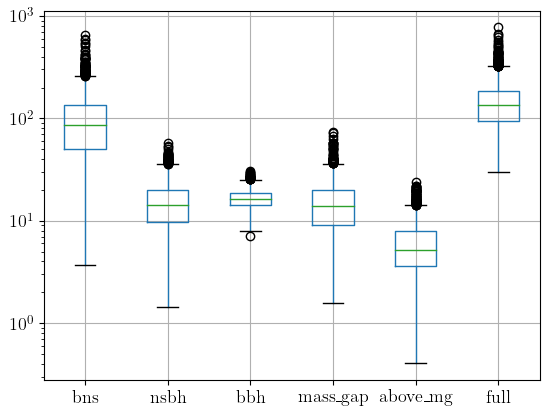

In [6]:
# let's look at the full rate distributions by loading in the result of the above calculation and plotting it
binned_rates = pd.read_csv(binned_rate_fname,delimiter='\t')
binned_rates.boxplot()
plt.yscale("log")
plt.show()